# New Section

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder


In [ ]:
df = pd.read_csv("Personalized_Healthcare_Dataset.csv")



In [ ]:
X = df[['age', 'blood_pressure', 'glucose_level', 'heart_rate']]
y = df['diagnosis']


In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)


In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 0.085
Classification Report:
                precision    recall  f1-score   support

      Allergy       0.16      0.11      0.13        27
       Asthma       0.00      0.00      0.00        12
     COVID-19       0.07      0.14      0.09        14
  Common Cold       0.09      0.10      0.09        21
     Diabetes       0.20      0.09      0.12        22
          Flu       0.15      0.12      0.14        16
    Gastritis       0.04      0.05      0.04        20
Heart Disease       0.00      0.00      0.00        20
 Hypertension       0.18      0.13      0.15        23
     Migraine       0.07      0.08      0.08        25

     accuracy                           0.09       200
    macro avg       0.10      0.08      0.08       200
 weighted avg       0.10      0.09      0.09       200



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack


In [ ]:
df = pd.read_csv("Large_Personalized_Healthcare_Dataset.csv")


In [ ]:
# Input features
X_vitals = df[['age', 'blood_pressure', 'glucose_level', 'heart_rate']]

# TF-IDF vectorization of symptoms
vectorizer = TfidfVectorizer()
X_symptoms = vectorizer.fit_transform(df['symptoms'])

# Combine symptoms and vitals
from scipy.sparse import csr_matrix
X_combined = hstack([X_symptoms, csr_matrix(X_vitals)])

# Encode target
le = LabelEncoder()
y = le.fit_transform(df['diagnosis'])



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)


In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

# Results
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


✅ Accuracy: 0.092

📊 Classification Report:
                precision    recall  f1-score   support

      Allergy       0.13      0.09      0.10       116
       Asthma       0.06      0.06      0.06        99
     COVID-19       0.06      0.07      0.06        74
  Common Cold       0.07      0.07      0.07       110
     Diabetes       0.11      0.11      0.11       107
          Flu       0.07      0.07      0.07       104
    Gastritis       0.13      0.11      0.12       107
Heart Disease       0.07      0.08      0.07        90
 Hypertension       0.10      0.08      0.09       106
     Migraine       0.12      0.18      0.15        87

     accuracy                           0.09      1000
    macro avg       0.09      0.09      0.09      1000
 weighted avg       0.09      0.09      0.09      1000



Shape: (5000, 10)

Columns: Index(['age', 'blood_pressure', 'glucose_level', 'heart_rate', 'symptoms',
       'diagnosis', 'prescribed_medicines', 'review', 'location',
       'visit_date'],
      dtype='object')

Missing Values:
 age                     0
blood_pressure          0
glucose_level           0
heart_rate              0
symptoms                0
diagnosis               0
prescribed_medicines    0
review                  0
location                0
visit_date              0
dtype: int64

Sample Rows:
    age  blood_pressure  glucose_level  heart_rate  \
0   56              96            155         130   
1   22             171            112         128   
2   30             162            246          76   
3   33             154            228         129   
4   67             174            208         105   

                                            symptoms     diagnosis  \
0                          fever, muscle pain, cough        Asthma   
1  chills, vomiting, s

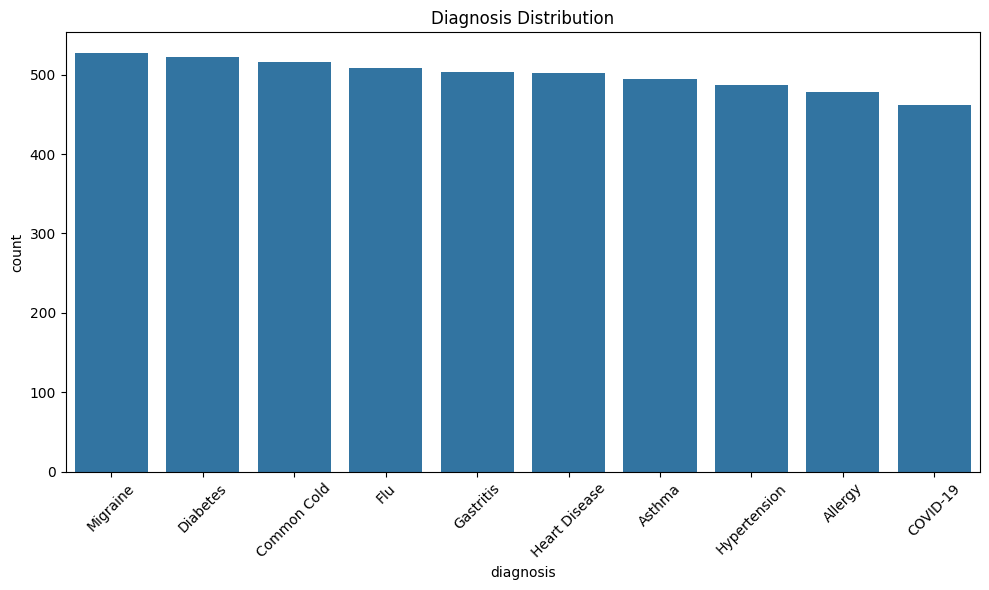

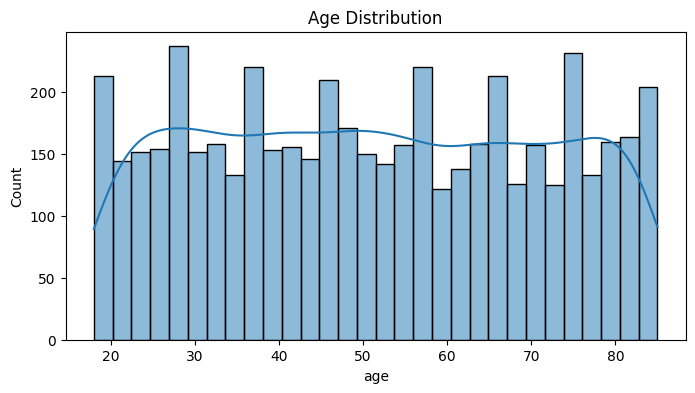

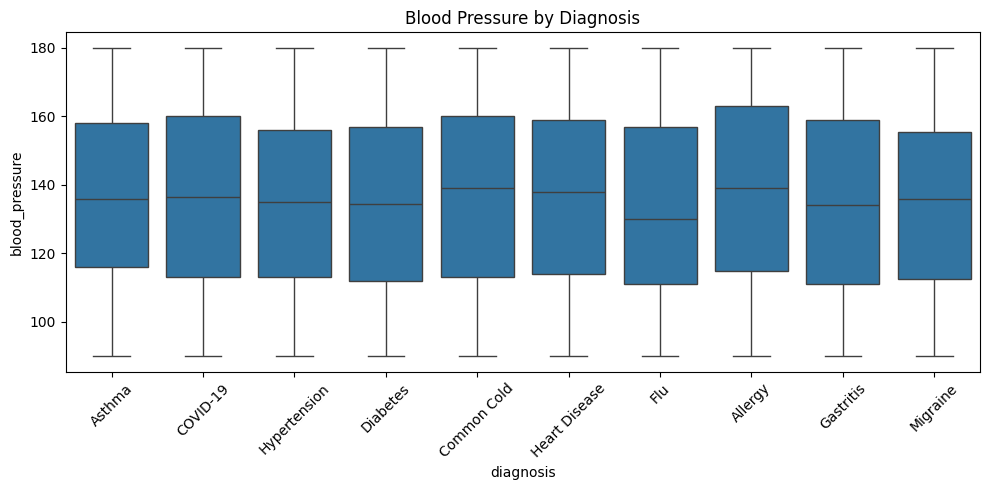

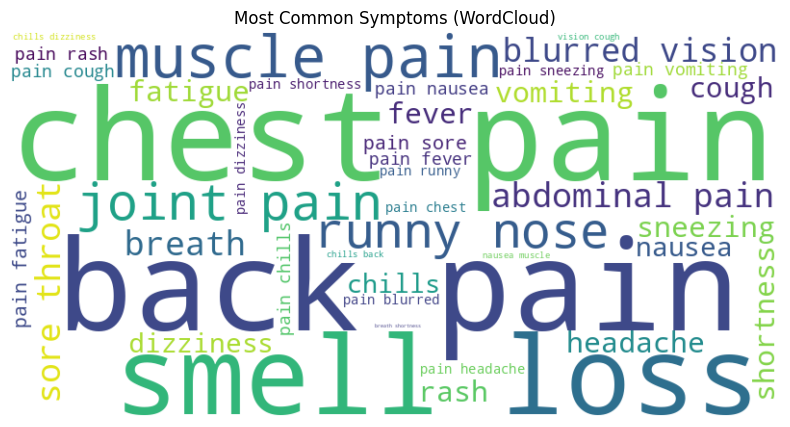

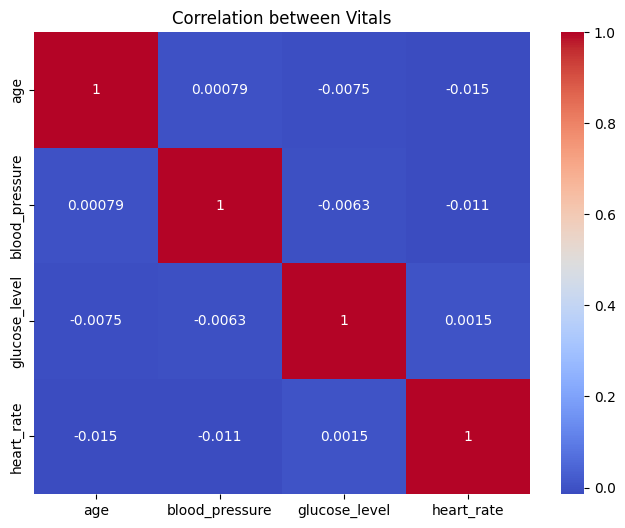


✅ Accuracy: 0.107

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.09      0.07      0.08       116
           1       0.11      0.08      0.09        99
           2       0.02      0.03      0.02        74
           3       0.12      0.13      0.13       110
           4       0.19      0.21      0.20       107
           5       0.18      0.16      0.17       104
           6       0.11      0.09      0.10       107
           7       0.08      0.10      0.09        90
           8       0.09      0.08      0.08       106
           9       0.07      0.10      0.08        87

    accuracy                           0.11      1000
   macro avg       0.11      0.10      0.10      1000
weighted avg       0.11      0.11      0.11      1000



In [ ]:
# 📊 EDA and Model Training - Healthcare Recommendation System

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Load data
df = pd.read_csv("Large_Personalized_Healthcare_Dataset.csv")

# Basic overview
print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nMissing Values:\n", df.isnull().sum())
print("\nSample Rows:\n", df.head())

# Diagnosis distribution
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='diagnosis', order=df['diagnosis'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Diagnosis Distribution")
plt.tight_layout()
plt.show()

# Age distribution
plt.figure(figsize=(8,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# Blood pressure vs diagnosis
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='diagnosis', y='blood_pressure')
plt.xticks(rotation=45)
plt.title("Blood Pressure by Diagnosis")
plt.tight_layout()
plt.show()

# WordCloud for Symptoms
text = " ".join(df['symptoms'].dropna().tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Symptoms (WordCloud)")
plt.show()

# Correlation heatmap of vitals
plt.figure(figsize=(8,6))
sns.heatmap(df[['age', 'blood_pressure', 'glucose_level', 'heart_rate']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between Vitals")
plt.show()

# Optional: Basic model to predict diagnosis
X = df[['age', 'blood_pressure', 'glucose_level', 'heart_rate']]
y = LabelEncoder().fit_transform(df['diagnosis'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\n✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
